# 成交量含大宗 (volume_btin) — 国家队注入模拟

---

## 1. 因子定义 (Wind 口径)

| 项目 | 内容 |
|------|------|
| **Wind 字段** | `s_dq_volume_btin` |
| **中文名** | 成交量 (含大宗交易) |
| **单位** | 股 (数据中为万股) |
| **算法** | 证券在指定交易日的成交量，包括大宗交易 |
| **来源** | 交易所公布值 |

> **核心含义**: 衡量 ETF 在交易所的当日总成交量（股数）。国家队场内买入直接增加成交量。注：自 2020 年 1 月 1 日起，统计口径为**单边计算**。

---

## 2. 国家队操作影响分析

### 场内买入 → **T+0** 立即影响成交量
- 国家队在交易所买入 ETF，成交的股数**当日即计入成交量**
- 买入金额 ÷ 成交均价 (≈ NAV) = 买入股数（万股）
- 影响直接确定

### 场外申购 → 对成交量 **无影响**
- 场外申购走一级市场（基金公司），不经过交易所撮合
- 交易所统计的成交量不包含一级市场的申赎

| 操作类型 | 是否影响 | 生效时间 | 原因 |
|---------|---------|---------|------|
| 场内买入 | **是** | **T+0** | 买入股数直接计入当日成交量 (单边) |
| 场外申购 | **否** | — | 一级市场不经过交易所，不计入成交量 |

---

## 3. Δ 计算公式

```text
Δvolume_btin = 买入金额 (万元) / NAV (元/份)   → 结果单位: 万股
```

**推导**: 买入金额 X 万元，按照 ETF 价格 (≈ NAV) 换算为成交股数 = X / NAV

**示例**: 场内买入 10 亿 (100,000 万元)，NAV = 3.09 元 → Δ = 100,000 / 3.09 ≈ 32,362 万股

---

## 4. 模拟 Pipeline

```text
原始值 (raw) → 注入 delta 到 T+0 日 → Rolling Z-Score (窗口120, 最小60) → 相对因子 = z(A) − z(B)
```

---

## 5. 参数说明

| 参数 | 含义 | 影响 |
|------|------|------|
| `NAV_A / NAV_B` | 单位净值 (元/份) | **直接决定 Δ**: 同样金额，NAV 越低成交股数越多 |
| `BUY_ON_EXCHANGE` | 场内买入总额 (亿元) | 唯一影响渠道 |
| `AUM_A / AUM_B` | 资产管理规模 (亿元) | 决定买入金额按持仓市值比例分配 |
| `HOLD_PCT_A / HOLD_PCT_B` | 国家队持有比例 | 持仓价值 = HOLD_PCT × AUM |
| `BUY_OFF_EXCHANGE` | 场外申购总额 (亿元) | 对本因子无影响，设为 0 |

---

## 6. 对大盘减小盘风格（y）的预期影响时间

> `y = 上证50日收益率 − 上证1000日收益率`。本因子作为**预测信号**，通过捕捉国家队资金偏好差异，预测大盘相对小盘的超额表现。

| 路径 | 预期影响时间 | 说明 |
|------|------------|------|
| 场内买入 → 通过本因子信号 | **T+0 ~ T+3** | 成交量当日（T+0）生效，叠加回归预测滞后 0–3 期；大宗成交量放大往往反映机构主动建仓 |
| 场内买入 → 直接价格冲击 | **T+0** | 买入当日大盘ETF价格上涨，y 直接受益 |

> **结论**: 国家队 T+0 出手 → 直接价格效应当日体现；通过本因子的信号传导，预期影响 y 的时间窗口见上表。


In [ ]:
# ══════════════ 参数设置 (修改这里) ══════════════

# ── ETF 代码 ──
CODE_A = "510050.SH"
CODE_B = "510100.SH"

# ── ETF 基础参数 (影响 delta 计算, 可根据实际值调整) ──
NAME_A  = "华夏上证50ETF"
NAME_B  = "易方达上证50ETF"
AUM_A   = 1750                # ETF A 资产管理规模 (亿元)
AUM_B   = 46                  # ETF B 资产管理规模 (亿元)
NAV_A   = 3.09                # ETF A 单位净值 (元/份) ← 用于Δ计算
NAV_B   = 2.93                # ETF B 单位净值 (元/份) ← 用于Δ计算
SHARES_A = 5_670_000          # ETF A 总份额 (万份)
SHARES_B = 157_000            # ETF B 总份额 (万份)
DAILY_AMT_A = 200_000         # ETF A 日均成交额 (万元)
DAILY_AMT_B = 50_000          # ETF B 日均成交额 (万元)

# ── 模拟设置 ──
SIM_DATE = "2024-09-24"
HOLD_PCT_A = 0.70
HOLD_PCT_B = 0.30

BUY_ON_EXCHANGE  = 30.0       # 场内买入 (亿元) → T+0
BUY_OFF_EXCHANGE = 30.0

ZOOM_HALF = 30

In [2]:
import datetime, sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath(".")))
sys.path.insert(0, ".")
from sim_utils import *
setup_style()

SHEET = "volume_btin"
UNIT = "万股"
LAG = 0

sim_date = datetime.datetime.strptime(SIM_DATE, "%Y-%m-%d").date()
on_a, on_b = buy_split(BUY_ON_EXCHANGE, AUM_A, AUM_B, HOLD_PCT_A, HOLD_PCT_B)

delta_a = on_a * 10000 / NAV_A if NAV_A > 0 else 0
delta_b = on_b * 10000 / NAV_B if NAV_B > 0 else 0

print(f"ETF对: {NAME_A} ({CODE_A}) vs {NAME_B} ({CODE_B})")
print(f"  AUM: {AUM_A}亿 vs {AUM_B}亿 | NAV: {NAV_A}元 vs {NAV_B}元")
print(f"场内买入: {BUY_ON_EXCHANGE}亿 → {NAME_A} {on_a:.2f}亿, {NAME_B} {on_b:.2f}亿")
print(f"\nΔ volume_btin:")
print(f"  {CODE_A}: +{delta_a:,.0f} {UNIT} (= {on_a*10000:,.0f}万元 / {NAV_A}元)")
print(f"  {CODE_B}: +{delta_b:,.0f} {UNIT} (= {on_b*10000:,.0f}万元 / {NAV_B}元)")

ETF对: 华夏上证50ETF (510050.SH) vs 易方达上证50ETF (510100.SH)
  AUM: 1750亿 vs 46亿 | NAV: 3.09元 vs 2.93元
场内买入: 30.0亿 → 华夏上证50ETF 29.67亿, 易方达上证50ETF 0.33亿

Δ volume_btin:
  510050.SH: +96,006 万股 (= 296,658万元 / 3.09元)
  510100.SH: +1,141 万股 (= 3,342万元 / 2.93元)


In [3]:
sheets_raw = load_raw()
df_orig = sheets_raw[SHEET]
all_dates = sorted(df_orig[DATE_COL].dropna().unique())
t1 = offset_date(all_dates, sim_date, 1)
t2 = offset_date(all_dates, sim_date, 2)
print(f"T+0={sim_date} (生效日)")

df_mod = inject_one(inject_one(df_orig, sim_date, CODE_A, delta_a), sim_date, CODE_B, delta_b)

z_before = zscore_sheet(df_orig)
z_after  = zscore_sheet(df_mod)
rel_before = relative_factor(z_before, CODE_A, CODE_B)
rel_after  = relative_factor(z_after, CODE_A, CODE_B)

zoom = zoom_range(all_dates, sim_date, ZOOM_HALF)
mask = df_orig[DATE_COL].isin(zoom)
dates = list(df_orig.loc[mask, DATE_COL])

T+0=2024-09-24 (生效日)


In [4]:
import importlib, sim_utils; importlib.reload(sim_utils); from sim_utils import *

print_detail(df_orig, df_mod, z_before, z_after,
             CODE_A, CODE_B, NAME_A, NAME_B, UNIT,
             sim_date, all_dates, effect_date=sim_date, half=5)


  华夏上证50ETF (510050.SH)  —  单位: 万股
          日期 |      raw_bef      raw_aft |   mean_bef   mean_aft |    std_bef    std_aft |   z_bef   z_aft      Δz |
-------------------------------------------------------------------------------------------------------------------
  2024-09-13 |       70,154       70,154 |     87,472     87,472 |     38,311     38,311 |  -0.452  -0.452  +0.000 |
  2024-09-18 |       98,630       98,630 |     87,504     87,504 |     38,319     38,319 |   0.290   0.290  +0.000 |
  2024-09-19 |      103,909      103,909 |     87,729     87,729 |     38,356     38,356 |   0.422   0.422  +0.000 |
  2024-09-20 |      189,297      189,297 |     89,208     89,208 |     39,669     39,669 |   2.523   2.523  +0.000 |
  2024-09-23 |       61,024       61,024 |     89,125     89,125 |     39,721     39,721 |  -0.707  -0.707  +0.000 |
  2024-09-24 |      199,454      295,459 |     90,464     91,531 |     41,371     45,267 |   2.634   4.505  +1.871 | ★T+0
  2024-09-25 |      161,

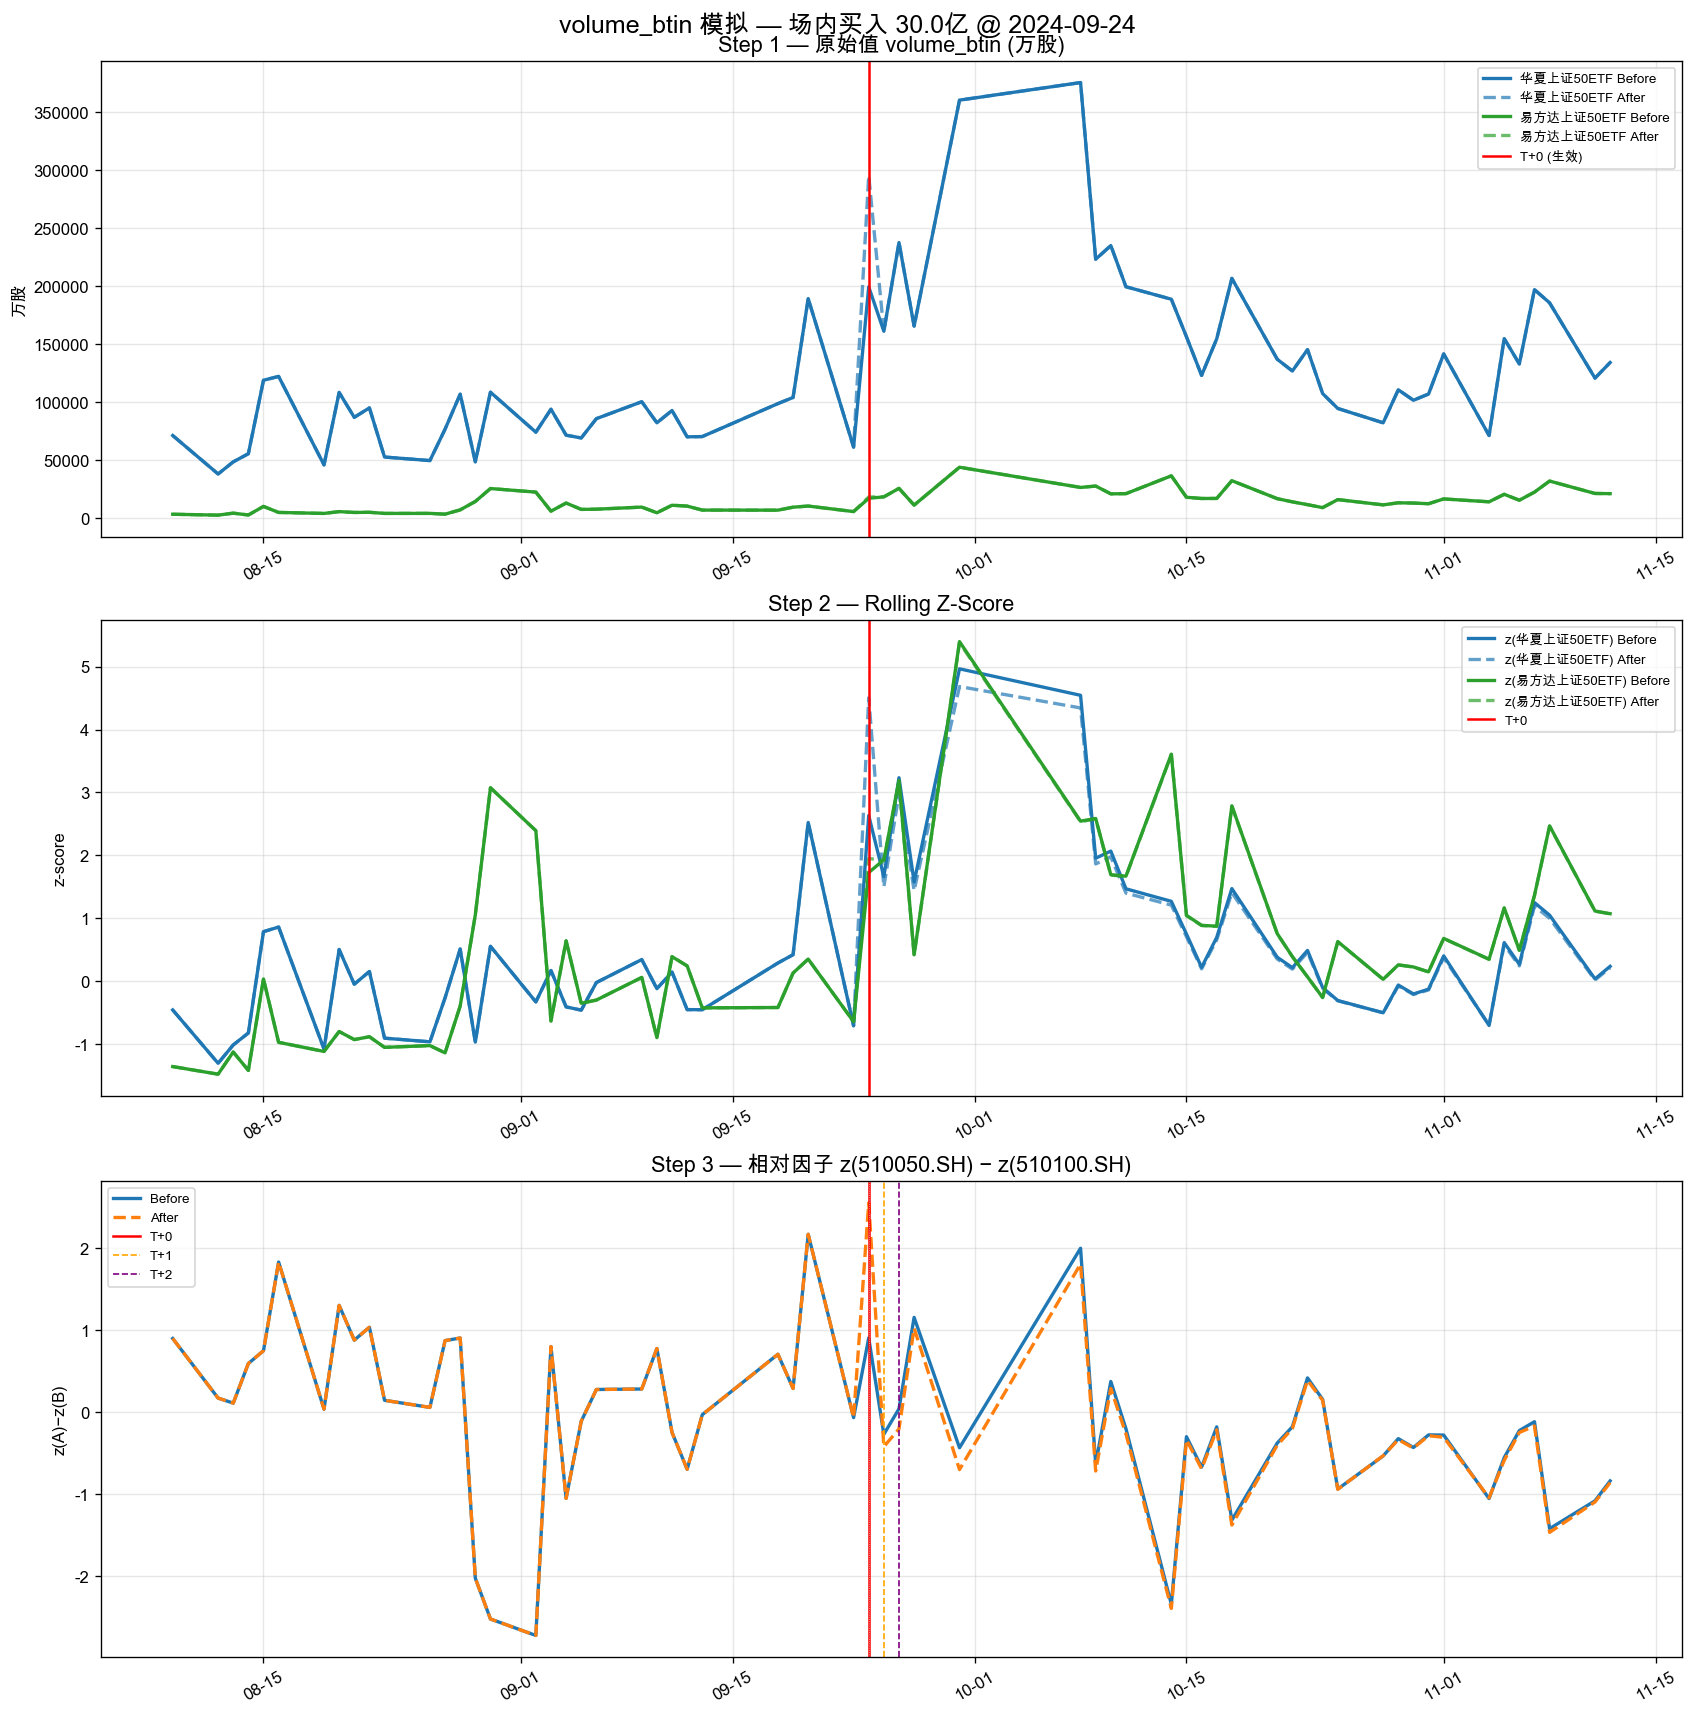

In [ ]:
import pandas as pd
fig, axes = plt.subplots(3, 1, figsize=(14, 14), constrained_layout=True)

for code, label, c in [(CODE_A, NAME_A, '#1f77b4'), (CODE_B, NAME_B, '#2ca02c')]:
    axes[0].plot(dates, pd.to_numeric(df_orig.loc[mask, code], errors='coerce').tolist(), label=f'{label} Before', color=c, lw=2)
    axes[0].plot(dates, pd.to_numeric(df_mod.loc[mask, code], errors='coerce').tolist(), label=f'{label} After', color=c, lw=2, ls='--', alpha=0.7)
axes[0].axvline(sim_date, color='red', lw=1.5, label='T+0 (生效)')
axes[0].set_title(f'Step 1 — 原始值 volume_btin ({UNIT})', fontsize=13)
axes[0].set_ylabel(UNIT); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d')); axes[0].tick_params(axis='x', rotation=30)

for code, label, c in [(CODE_A, NAME_A, '#1f77b4'), (CODE_B, NAME_B, '#2ca02c')]:
    axes[1].plot(dates, z_before.loc[mask, code].tolist(), label=f'z({label}) Before', color=c, lw=2)
    axes[1].plot(dates, z_after.loc[mask, code].tolist(), label=f'z({label}) After', color=c, lw=2, ls='--', alpha=0.7)
axes[1].axvline(sim_date, color='red', lw=1.5, label='T+0')
axes[1].set_title('Step 2 — Rolling Z-Score', fontsize=13)
axes[1].set_ylabel('z-score'); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d')); axes[1].tick_params(axis='x', rotation=30)

plot_ba(axes[2], dates, rel_before[mask].tolist(), rel_after[mask].tolist(),
        f'Step 3 — 相对因子 z({CODE_A}) − z({CODE_B})', 'z(A)−z(B)', sim_date, t1, t2)

plt.suptitle(f'volume_btin 模拟 — 场内买入 {BUY_ON_EXCHANGE}亿 @ {SIM_DATE}', fontsize=15, y=1.01)
plt.show()